In [38]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
df_filtered = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()
df_filtered['type'] = df_filtered['type'].map({'CASH_OUT': 1, 'TRANSFER': 2})

In [39]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,840",C1231006815,"170,136","160,296",M1979787155,0,0,0,0
1,1,PAYMENT,"1,864",C1666544295,"21,249","19,385",M2044282225,0,0,0,0
2,1,TRANSFER,181,C1305486145,181,0,C553264065,0,0,1,0
3,1,CASH_OUT,181,C840083671,181,0,C38997010,"21,182",0,1,0
4,1,PAYMENT,"11,668",C2048537720,"41,554","29,886",M1230701703,0,0,0,0


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [41]:
print(df.isnull().sum())
print(df.duplicated().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
0


In [42]:
print(df['isFraud'].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


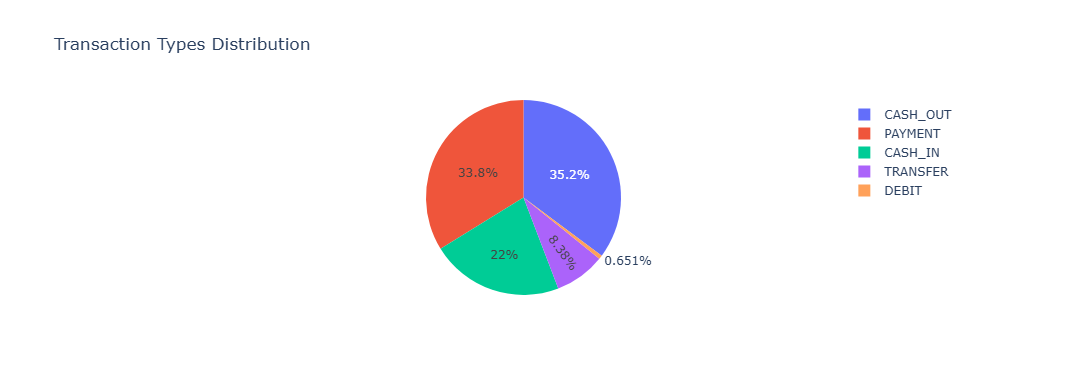

       type  fraud_rate
0   CASH_IN           0
1  CASH_OUT           0
2     DEBIT           0
3   PAYMENT           0
4  TRANSFER           1


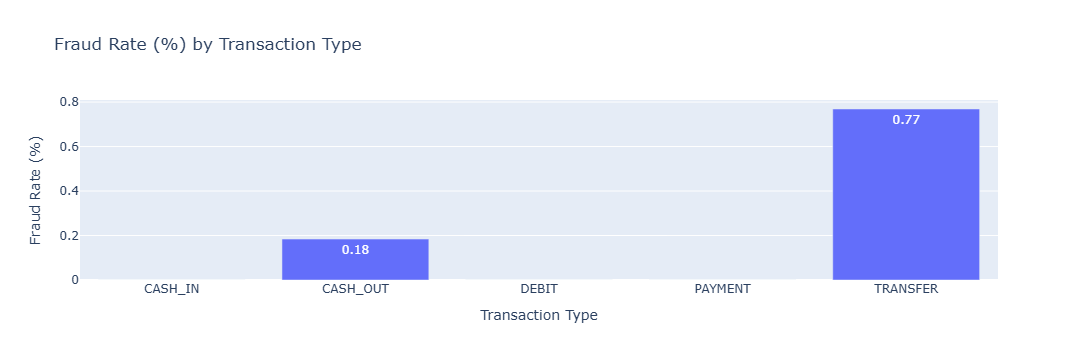

In [43]:
type_counts = df['type'].value_counts().reset_index()
type_counts.columns = ['type', 'count']
fig1 = px.pie(type_counts, values='count', names='type', title='Transaction Types Distribution')
fig1.show()

fraud_rate = (df.groupby('type')['isFraud'].mean() * 100).reset_index()
fraud_rate.columns = ['type', 'fraud_rate']
print(fraud_rate)

fig2 = px.bar(fraud_rate, x='type', y='fraud_rate', 
              title='Fraud Rate (%) by Transaction Type',
              labels={'fraud_rate': 'Fraud Rate (%)', 'type': 'Transaction Type'},
              text_auto='.2f')
fig2.show()

In [44]:
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')

fraud_only = df[df['isFraud'] == 1]
print(fraud_only['amount'].describe())

non_fraud = df[df['isFraud'] == 0]
print(non_fraud['amount'].describe())

count        8,213
mean     1,467,967
std      2,404,253
min              0
25%        127,091
50%        441,423
75%      1,517,771
max     10,000,000
Name: amount, dtype: float64
count    6,354,407
mean       178,197
std        596,237
min              0
25%         13,368
50%         74,685
75%        208,365
max     92,445,517
Name: amount, dtype: float64


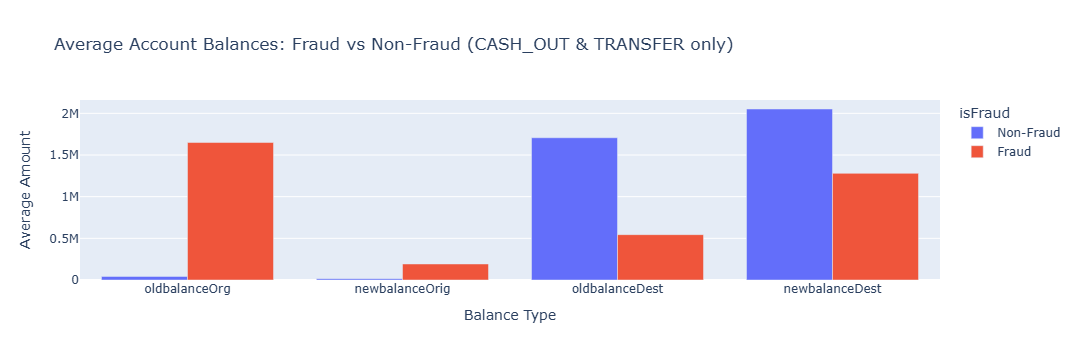

In [45]:
balance_cols = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

balance_summary = df_filtered.groupby('isFraud')[balance_cols].mean().reset_index()
balance_summary['isFraud'] = balance_summary['isFraud'].map({0: 'Non-Fraud', 1: 'Fraud'})

balance_melted = balance_summary.melt(id_vars='isFraud', value_vars=balance_cols, 
                                        var_name='Balance Type', value_name='Average Amount')

fig3 = px.bar(balance_melted, x='Balance Type', y='Average Amount', color='isFraud', barmode='group',
             title='Average Account Balances: Fraud vs Non-Fraud (CASH_OUT & TRANSFER only)')
fig3.show()

In [46]:
df['nameDest_prefix'] = df['nameDest'].str[0]
print(df.groupby('nameDest_prefix')['isFraud'].value_counts())
# redundant with 'type', so not used as a feature

nameDest_prefix  isFraud
C                0          4202912
                 1             8213
M                0          2151495
Name: count, dtype: int64


In [47]:
df_filtered['errorBalanceOrig'] = df_filtered['newbalanceOrig'] + df_filtered['amount'] - df_filtered['oldbalanceOrg']
df_filtered['errorBalanceDest'] = df_filtered['oldbalanceDest'] + df_filtered['amount'] - df_filtered['newbalanceDest']

feature_cols = [
    'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
    'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest'
]
X = df_filtered[feature_cols]
y = df_filtered['isFraud']

In [48]:
print(X.head())
print(y.head())

    type  amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
2      2     181            181               0               0   
3      1     181            181               0          21,182   
15     1 229,134         15,325               0           5,083   
19     2 215,310            705               0          22,425   
24     2 311,686         10,835               0           6,267   

    newbalanceDest  errorBalanceOrig  errorBalanceDest  
2                0                 0               181  
3                0                 0            21,363  
15          51,513           213,809           182,704  
19               0           214,605           237,735  
24       2,719,173           300,851        -2,401,220  
2     1
3     1
15    0
19    0
24    0
Name: isFraud, dtype: int64


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2216327, 8)
Test size: (554082, 8)


In [50]:
model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [51]:
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 1.0000


In [52]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[552436      3]
 [     6   1637]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       1.00      1.00      1.00      1643

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082



In [53]:
sample = X_test.iloc[[0]]
actual = y_test.iloc[0]
prediction = model.predict(sample)

print("Sample features:\n", sample)
print("Actual isFraud:", actual)
print("Predicted isFraud:", prediction[0])

Sample features:
          type  amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
5582560     1 226,596              0               0         471,074   

         newbalanceDest  errorBalanceOrig  errorBalanceDest  
5582560         697,670           226,596                 0  
Actual isFraud: 0
Predicted isFraud: 0
